# **Тема: Опровержение гипотезы Гольдбаха в системе компьютерной алгебры Sage**

In [78]:
import time
from sage.parallel.decorate import parallel
import matplotlib.pyplot as plt
import numpy as np
import random

Эта функция позволяет проверить, удовлетворяет ли четное число гипотезе Гольдбаха. Эту функцию необходимо оптимизировать.

In [79]:
def check_gc_sequential(n):
    if n <= 2 or n % 2 != 0:
        return False

    for p in primes(n//2 + 1):
        q = n - p
        if is_prime(q):
            return True
            
    print('!!!!!!!!!!!!!! ALERT !!!!!!!!!!!!!!!!!!!!!')        
    print(f'The even number {n} doesn\'t satisfied the goldbach conjecture.')
    return False

Это оптимизированная функция, полученная с использованием метода параллелизма.

In [80]:
@parallel
def check_gc_parallel(n):
    if n <= 2 or n % 2 != 0:
        return False

    for p in primes(n//2 + 1):
        q = n - p
        if is_prime(q):
            return True
            
    print('!!!!!!!!!!!!!! ALERT !!!!!!!!!!!!!!!!!!!!!')        
    print(f'The even number {n} doesn\'t satisfied the goldbach conjecture.')
    return False

Эта функция просто выводит время выполнения.

In [81]:
def show_exec_time(exec_time):
    if exec_time < 60:
        print(f'The execution time is {exec_time:.4f}s.')
    else:
        print(f'The execution time is {(exec_time/60):.4f}min.')

Ниже мы вычисляем время выполнения, необходимое для проверки того, соответствуют ли пары чисел в интервале 10^6 и 10^7 гипотезе Гольдбаха без использования метода параллелизма.

In [82]:
start = time.time()
for i in range(10**6, 10**7, 2):
    check_gc_sequential(i)
exec_time = time.time() - start
show_exec_time(exec_time)

The execution time is 1.0035min.


Ниже мы вычисляем время выполнения, необходимое для проверки соответствия парных чисел в интервале 10^6 и 10^7 гипотезе Гольдбаха с использованием метода параллелизма.

In [83]:
start = time.time()
check_gc_parallel(list(range(10**6, 10**7, 2)))
exec_time = time.time() - start
show_exec_time(exec_time)

The execution time is 0.2228s.


Реализация теста Миллера-Рабина на простоту чисел большого размера

In [84]:
def is_probable_prime(n, k=10):
    
    if n < 2:
        return False
    if n in (2, 3):
        return True
    if n % 2 == 0:
        return False

    s = 0
    d = n - 1
    while d % 2 == 0:
        s += 1
        d //= 2

    for _ in range(k):
        a = random.randint(2, n - 2)
        x = pow(a, d, n)
        if x == 1 or x == n - 1:
            continue
        for _ in range(s - 1):
            x = pow(x, 2, n)
            if x == n - 1:
                break
        else:
            return False
    return True

Приведенная ниже функция позволяет по умолчанию генерировать большое число от 10<sup>19</sup> до 10<sup>20</sup>.

In [85]:
def generate_random_even_number(min_val=10**19, max_val=10**20):
    
    num = random.randint(min_val, max_val)
    
    if num % 2 != 0:
        num += 1

    return num

Приведенная ниже функция позволяет проверить, удовлетворяет ли большое число гипотезе Гольдбаха.

In [86]:
def check_gc_BigNum(n):
    if n < 4 or n % 2 != 0:
        return None

    offset = 0
    while offset < n // 4:
        for sign in [-1, 1]:
            p1 = n // 2 + sign * offset
            if p1 % 2 == 0:
                p1 += sign
            if 3 <= p1 < n - 3:
                if is_probable_prime(p1):
                    p2 = n - p1
                    if is_probable_prime(p2):
                        return (min(p1, p2), max(p1, p2))
        offset += 2

    return None

В приведенном ниже коде мы случайным образом генерируем 10 больших чисел и пытаемся найти для каждого из них одно разбиение Гольдбаха.

In [87]:
large_numbers = [str(generate_random_even_number()) for _ in range(10)]
goldbach_partitions = [str(check_gc_BigNum(int(x))) for x in large_numbers]

In [88]:
data = [large_numbers, goldbach_partitions]

t = table(np.array(data).T.tolist(), 
          header_row = ['Large Numbers', 'Goldbach Partitions'],
          header_column=True,
          frame = True
         )
show(t)

Large Numbers,Goldbach Partitions
86163607453494510482,"(43081803726747253099, 43081803726747257383)"
90286642614770863290,"(45143321307385431223, 45143321307385432067)"
65919222365180180848,"(32959611182590090121, 32959611182590090727)"
56872494392132360194,"(28436247196066179647, 28436247196066180547)"
76805250723134370730,"(38402625361567183193, 38402625361567187537)"
94430064541233973350,"(47215032270616986253, 47215032270616987097)"
26445572789240031352,"(13222786394620015223, 13222786394620016129)"
88720813996145788206,"(44360406998072893129, 44360406998072895077)"
55209236357816502810,"(27604618178908250423, 27604618178908252387)"
63040930356024044964,"(31520465178012022207, 31520465178012022757)"


Приведенная ниже функция вычисляет количество разбиений Гольдбаха для четного числа разбиений.

In [89]:
def n_pairs_primes(n):
    if n <= 2 or n % 2 != 0:
        return 0
    
    qty = 0    
    for p in primes(n//2 + 1):
        q = n - p
        if is_prime(q):
            qty += 1
            
    return qty

Построить график зависимости числа способов представления четного числа от 2n
Кроме того, имеются линейные модели, отражающие различные тенденции на графике.`

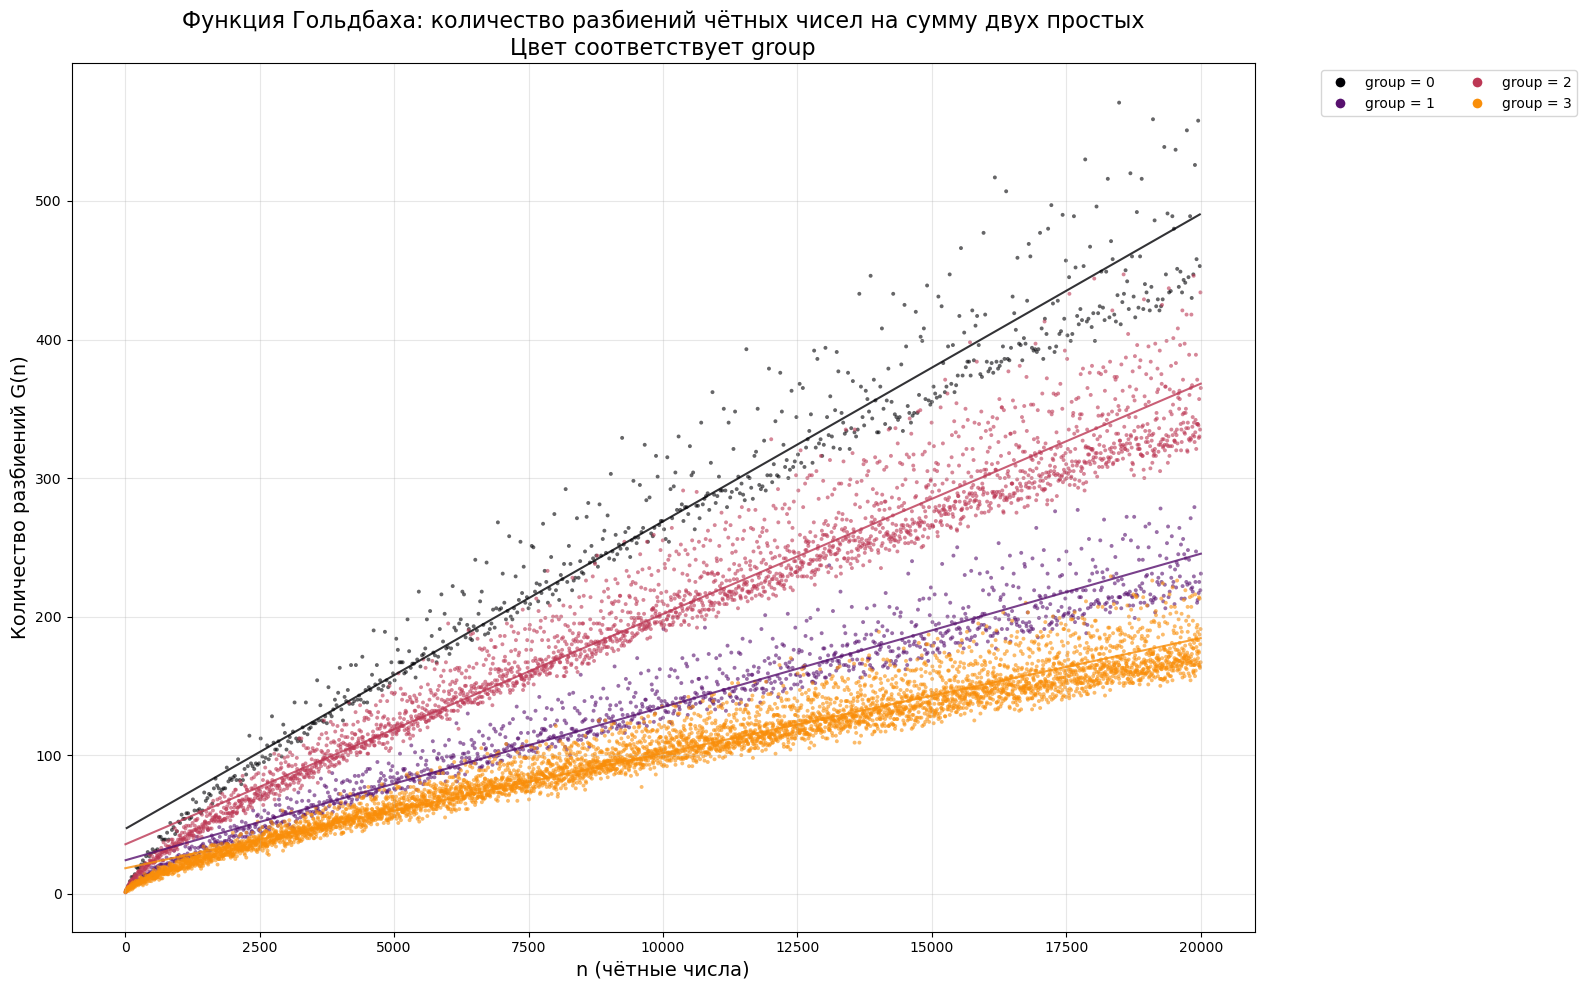

In [90]:
max_n = 10000 * 2

x_values = list(range(4, max_n + 1, 2))
y_values = [n_pairs_primes(n) for n in x_values]


groups = []
for x in x_values:
  if x % 3 == 0 and x % 5 == 0:
    groups.append(0)
  elif x % 5 == 0:
    groups.append(1)
  elif x % 3 == 0:
    groups.append(2)
  else:
    groups.append(3)


unique_group = sorted(set(groups))
colors = plt.cm.inferno(np.linspace(0, 1, len(unique_group) + 1))
group_to_color = {group: colors[i] for i, group in enumerate(unique_group)}

plt.figure(figsize=(16, 10))

global coefficients
coefficients = []

for g in unique_group:
  mask = [g == group for group in groups]
  x_group = np.array(x_values)[mask]
  y_group = np.array(y_values)[mask]

  plt.scatter(x_group, y_group, c=[group_to_color[g]], s=8, alpha=0.6,
              label=f'group: {g}', edgecolors='none')

  k, b = np.polyfit(x_group, y_group, 1)
  coefficients.append([k, b])
  x_line = np.linspace(min(x_group), max(x_group), 100)
  plt.plot(x_line, k * x_line + b, '-', linewidth=1.5,
            color=group_to_color[g], alpha=0.8)


plt.xlabel('n (чётные числа)', fontsize=14)
plt.ylabel('Количество разбиений G(n)', fontsize=14)
plt.title('Функция Гольдбаха: количество разбиений чётных чисел на сумму двух простых\n'
          'Цвет соответствует group', fontsize=16)
plt.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=group_to_color[group],
                      markersize=8, label=f'group = {group}')
            for group in unique_group]

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left',
          ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

Приведенная ниже функция позволяет предсказать количество разбиений Гольдбаха для заданного четного числа.

In [91]:
def predict_nbr_goldbach_partitions(n, coeff = coefficients):
    coefficients = np.array(coeff)
    X = np.array([[n],[1]])
    if x % 3 == 0 and x % 5 == 0:
        return coefficients[0].dot(X)        
    elif x % 5 == 0:
        return coefficients[1].dot(X)
    elif x % 3 == 0:
        return coefficients[2].dot(X)
    else:
        return coefficients[3].dot(X)


В приведенном ниже коде мы генерируем 10 случайных четных чисел и пытаемся предсказать количество разбиений Гольдбаха, а затем сравниваем его с фактическим количеством разбиений Гольдбаха для каждого из них.

In [92]:
small_numbers = [str(generate_random_even_number(2500, 10**6)) for _ in range(10)] 
pred_values_sn = [str(f'{predict_nbr_goldbach_partitions(int(num))[0]:.2f}') for num in small_numbers]
actual_values_sn = [str(n_pairs_primes(int(num))) for num in small_numbers]
data_2 = [small_numbers, actual_values_sn, pred_values_sn]

t = table(np.array(data_2).T.tolist(), 
          header_row = ['Small Numbers', 'Actual Values', 'Predictions'],
          header_column=True,
          frame = True
         )
show(t)


Small Numbers,Actual Values,Predictions
369530,2842,4114.01
690534,6525,7666.89
781340,5236,8671.94
855968,3670,9497.92
9842,129,132.96
726968,3465,8070.15
131814,1506,1482.96
222058,1178,2481.78
637364,3899,7078.40
315050,2050,3511.02


В приведенном ниже коде мы используем наш список из 10 больших четных чисел, сгенерированный ранее, и пытаемся предсказать количество разбиений Гольдбаха для каждого из них.

In [93]:
pred_values_ln = [str(f'{predict_nbr_goldbach_partitions(int(num))[0]:.2f}') for num in large_numbers]

data_3 = [large_numbers, pred_values_ln]

t = table(np.array(data_3).T.tolist(), 
          header_row = ['Large Numbers', 'Predictions'],
          header_column=True,
          frame = True
         )
show(t)

Large Numbers,Predictions
86163607453494510482,953662623611857664.00
90286642614770863290,999296559392331776.00
65919222365180180848,729596872799939840.00
56872494392132360194,629467286900972672.00
76805250723134370730,850083916824448512.00
94430064541233973350,1045156136792853504.00
26445572789240031352,292700770945752192.00
88720813996145788206,981965898888470144.00
55209236357816502810,611058273308948992.00
63040930356024044964,697739809358690304.00
